# **Lab 7(B) - Mathematical and Statistical Filters**

In [7]:
import cv2
import numpy as np

from IPython.display import Image, display
from matplotlib import pyplot as plt

plt.rc('text', usetex=False)

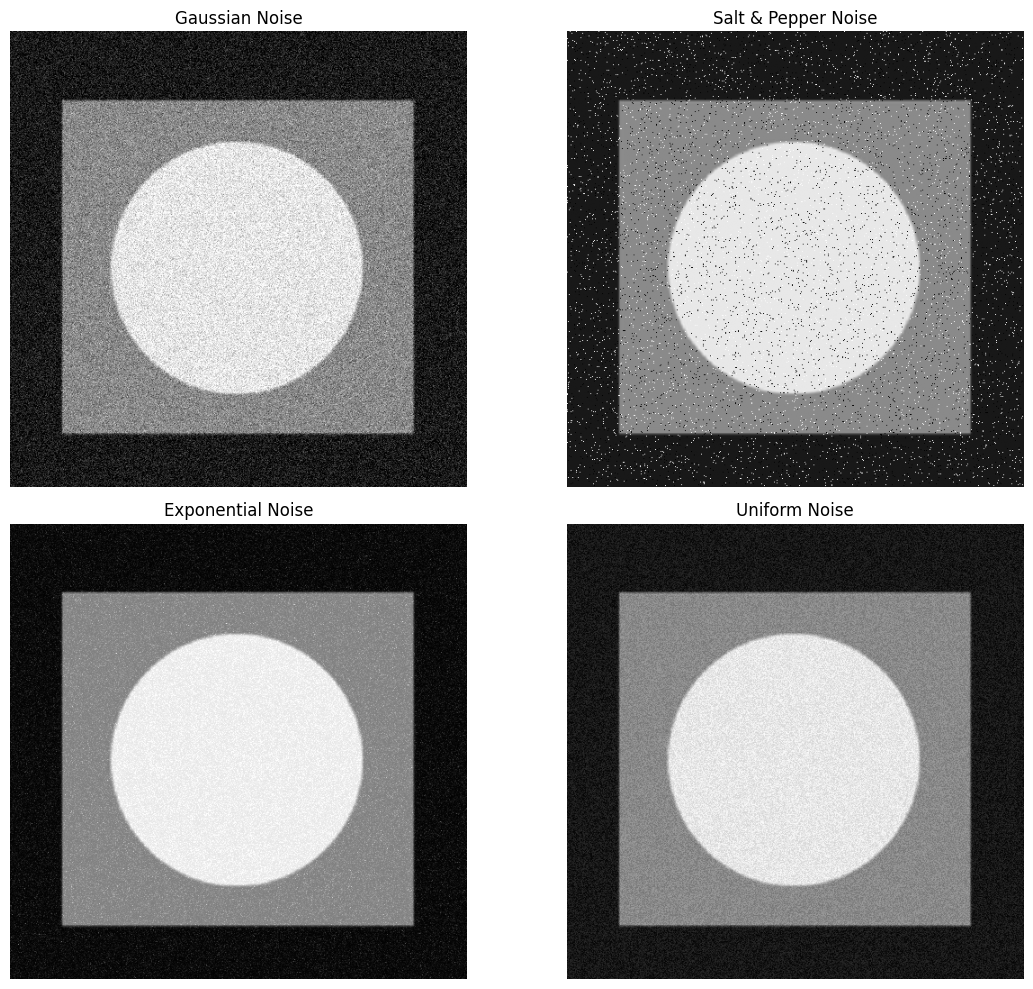

In [8]:
# ========== ( Adding nosie to an Image ) =================

# 0. Read an Image
imgPath = 'noise.jpg'
img = cv2.imread(imgPath, 0)

# 1. Function that handle all noise algorithm (Guassian, Exp, Uniform & Salt&Pepper)
def add_noise(image, noise_type):
    row, col = image.shape

    if noise_type == "gaussian":
        mean = 0
        var = 0.01  # Adjust for more/less noise
        sigma = var**0.5
        gauss = np.random.normal(mean, sigma, (row, col))
        noisy = image / 255 + gauss
        return np.clip(noisy * 255, 0, 255).astype(np.uint8)

    elif noise_type == "salt_pepper":
        s_vs_p = 0.5
        amount = 0.04
        noisy = np.copy(image)
        # Salt (white pixels)
        num_salt = np.ceil(amount * image.size * s_vs_p)
        coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
        noisy[tuple(coords)] = 255
        # Pepper (black pixels)
        num_pepper = np.ceil(amount * image.size * (1.0 - s_vs_p))
        coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
        noisy[tuple(coords)] = 0
        return noisy

    elif noise_type == "exponential":
        # Scale is the inverse of the rate (lambda)
        expo = np.random.exponential(scale=10.0, size=(row, col))
        noisy = image + expo
        return np.clip(noisy, 0, 255).astype(np.uint8)

    elif noise_type == "uniform":
        low = -20
        high = 20
        uni = np.random.uniform(low, high, (row, col))
        noisy = image + uni
        return np.clip(noisy, 0, 255).astype(np.uint8)



# 2. Load image in grayscale
img = cv2.imread(imgPath, 0)

# 3. Generate Noisy Images
noise_gauss = add_noise(img, "gaussian")
noise_sp = add_noise(img, "salt_pepper")
noise_expo = add_noise(img, "exponential")
noise_uni = add_noise(img, "uniform")

# 4. Display in 2x2 Grid
plt.figure(figsize=(12, 10))

plt.subplot(221), plt.imshow(noise_gauss, cmap='gray'), plt.title('Gaussian Noise')
plt.subplot(222), plt.imshow(noise_sp, cmap='gray'), plt.title('Salt & Pepper Noise')
plt.subplot(223), plt.imshow(noise_expo, cmap='gray'), plt.title('Exponential Noise')
plt.subplot(224), plt.imshow(noise_uni, cmap='gray'), plt.title('Uniform Noise')

for i in range(1, 5):
    plt.subplot(220 + i).axis('off')

plt.tight_layout()
plt.show()


array([[18, 25, 23, ..., 18, 15, 29],
       [20, 23, 22, ..., 18, 19, 28],
       [19, 20, 19, ..., 17, 18, 19],
       ...,
       [39, 32, 36, ..., 24, 24, 27],
       [46, 38, 44, ..., 27, 22, 23],
       [32, 31, 41, ..., 30, 33, 29]], dtype=uint8)
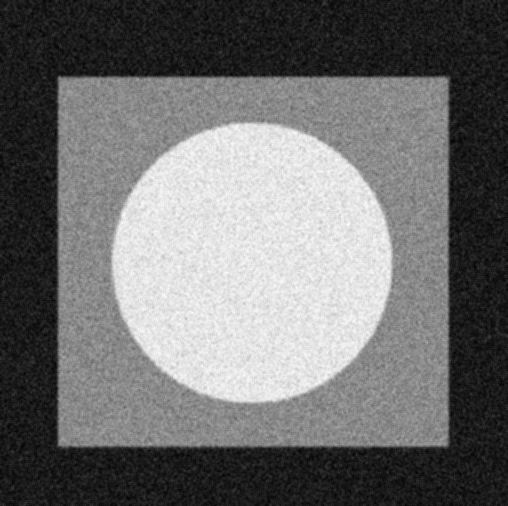

In [9]:
# --- METHOD 1: Using Built-in OpenCV function ---

# 2. Apply Arithmetic Mean Filter (using a 5x5 blur window)
# The larger the numbers in (3, 3), the smoother the image becomes.,
# you can change kernel size to (5,5), (7,7) etc.
filtered_img = cv2.blur(noise_gauss, (3, 3))

display(filtered_img)

array([[24, 24, 24, ..., 24, 24, 24],
       [24, 24, 24, ..., 24, 24, 24],
       [24, 24, 24, ..., 24, 24, 24],
       ...,
       [24, 24, 24, ..., 24, 24, 24],
       [24, 24, 24, ..., 24, 24, 24],
       [24, 24, 24, ..., 24, 24, 24]], dtype=uint8)
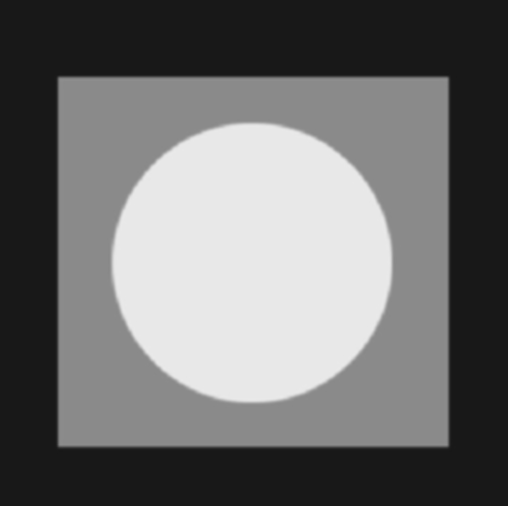

In [10]:
# --- METHOD 2: Manual implementation using a Kernel ---

# An Arithmetic Mean kernel is just a matrix of 1s divided by the total number of pixels.
kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size * kernel_size)
arithmetic_mean_manual = cv2.filter2D(img, -1, kernel)

display(arithmetic_mean_manual)

## **Geometric Means**

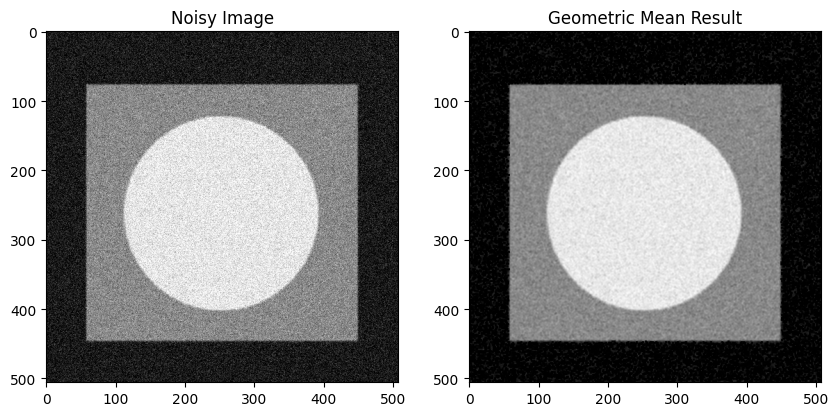

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def geometric_mean_filter(image, kernel_size=3):
    # 1. Convert to float64 and add a tiny epsilon to avoid log(0)
    img_float = image.astype(np.float64) + 1e-6

    # 2. Apply the log-transform
    log_img = np.log(img_float)

    # 3. Apply a box filter to the log image (calculates the average of logs)
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size * kernel_size)
    mean_log = cv2.filter2D(log_img, -1, kernel)

    # 4. Take the exponent to get back to the geometric mean
    geo_mean = np.exp(mean_log)

    # 5. Clip and convert back to 8-bit
    return np.clip(geo_mean, 0, 255).astype(np.uint8)


# === List of noisy images
# noise_gauss = add_noise(img, "gaussian")
# noise_sp = add_noise(img, "salt_pepper")
# noise_expo = add_noise(img, "exponential")
# noise_uni = add_noise(img, "uniform")

noise_img = noise_gauss

# Apply filter
result = geometric_mean_filter(noise_img, kernel_size=3)

# Display Comparison
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(noise_img, cmap='gray'), plt.title('Noisy Image')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Geometric Mean Result')
plt.show()


## **Harmonic Means Filter**

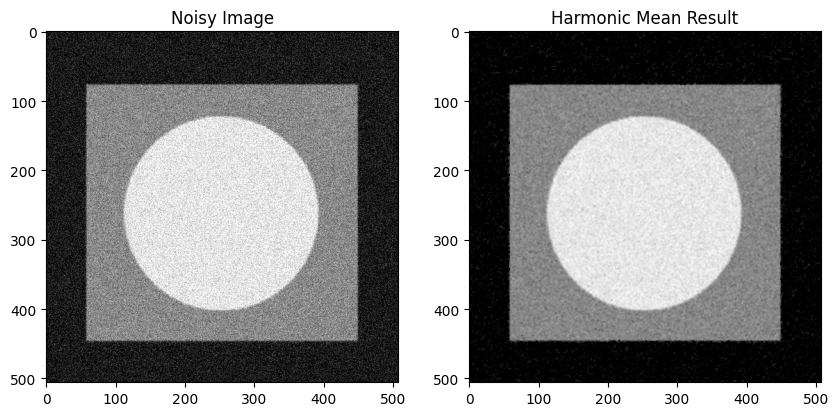

In [13]:

def harmonic_mean_filter(image, kernel_size=3):
    # 1. Convert to float64 to avoid overflow during calculation
    # Add a tiny epsilon to handle black pixels (0)
    img_float = image.astype(np.float64) + 1e-6

    # 2. Calculate the reciprocal of every pixel (1/P)
    reciprocal_img = 1.0 / img_float

    # 3. Sum the reciprocals in a window and divide by window size
    # This is equivalent to applying a standard mean filter to the reciprocal image
    kernel = np.ones((kernel_size, kernel_size), np.float32)
    sum_reciprocal = cv2.filter2D(reciprocal_img, -1, kernel)

    # 4. Final step of the formula: (Window Size) / Sum of Reciprocals
    # Note: Window size is kernel_size * kernel_size
    n = kernel_size * kernel_size
    harmonic_mean = n / sum_reciprocal

    # 5. Clip the results and convert back to 8-bit
    return np.clip(harmonic_mean, 0, 255).astype(np.uint8)


# === List of noisy images
# noise_gauss = add_noise(img, "gaussian")
# noise_sp = add_noise(img, "salt_pepper")
# noise_expo = add_noise(img, "exponential")
# noise_uni = add_noise(img, "uniform")

noise_img = noise_gauss

# Apply the filter
cleaned_img = harmonic_mean_filter(noise_img, kernel_size=3)

# Display Comparison
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(noise_img, cmap='gray'), plt.title('Noisy Image')
plt.subplot(122), plt.imshow(cleaned_img, cmap='gray'), plt.title('Harmonic Mean Result')
plt.show()


## **Contra - Harmonic Mean Filter**

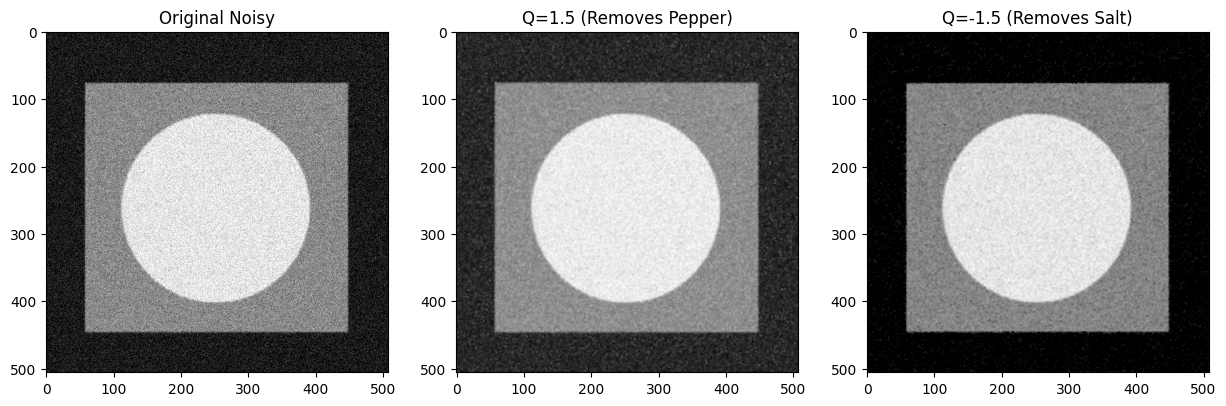

In [14]:


def contra_harmonic_mean(image, kernel_size=3, Q=0):
    # 1. Convert to float to handle high powers and prevent overflow
    img_float = image.astype(np.float64) + 1e-6

    # 2. Calculate numerator: Sum of pixels to the power (Q + 1)
    numerator = np.power(img_float, Q + 1)
    kernel = np.ones((kernel_size, kernel_size), np.float32)
    num_sum = cv2.filter2D(numerator, -1, kernel)

    # 3. Calculate denominator: Sum of pixels to the power (Q)
    denominator = np.power(img_float, Q)
    den_sum = cv2.filter2D(denominator, -1, kernel)

    # 4. Divide and clean up
    # Handle potential division by zero
    result = num_sum / (den_sum + 1e-6)

    return np.clip(result, 0, 255).astype(np.uint8)

# === List of noisy images
# noise_gauss = add_noise(img, "gaussian")
# noise_sp = add_noise(img, "salt_pepper")
# noise_expo = add_noise(img, "exponential")
# noise_uni = add_noise(img, "uniform")

noise_img = noise_gauss

# --- APPLICATIONS ---
# Q > 0 (e.g., 1.5): Removes Pepper Noise (black spots)
pepper_removed = contra_harmonic_mean(noise_img, kernel_size=3, Q=1.5)

# Q < 0 (e.g., -1.5): Removes Salt Noise (white spots)
salt_removed = contra_harmonic_mean(noise_img, kernel_size=3, Q=-1.5)

# --- DISPLAY ---
plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(noise_img, cmap='gray'), plt.title('Original Noisy')
plt.subplot(132), plt.imshow(pepper_removed, cmap='gray'), plt.title('Q=1.5 (Removes Pepper)')
plt.subplot(133), plt.imshow(salt_removed, cmap='gray'), plt.title('Q=-1.5 (Removes Salt)')
plt.show()


## **Median Filter**

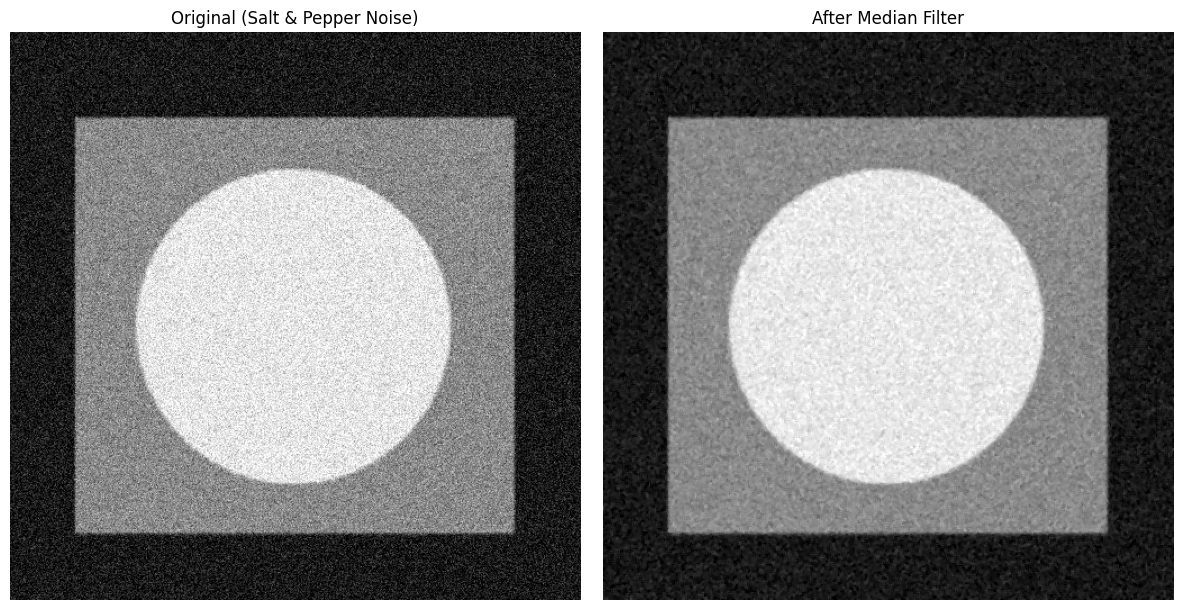

In [15]:



# === List of noisy images
# noise_gauss = add_noise(img, "gaussian")
# noise_sp = add_noise(img, "salt_pepper")
# noise_expo = add_noise(img, "exponential")
# noise_uni = add_noise(img, "uniform")

noise_img = noise_gauss

# 2. Apply Median Filter
# The second argument is the 'ksize' (kernel size).
# It MUST be an odd integer (3, 5, 7, etc.)
median_result = cv2.medianBlur(noise_img, 3)

# 3. Compare Results
plt.figure(figsize=(12, 6))

plt.subplot(121), plt.imshow(noise_img, cmap='gray'), plt.title('Original (Salt & Pepper Noise)'), plt.axis('off')
plt.subplot(122), plt.imshow(median_result, cmap='gray'), plt.title('After Median Filter'), plt.axis('off')
plt.tight_layout()
plt.show()


## **Max and Min Filter**

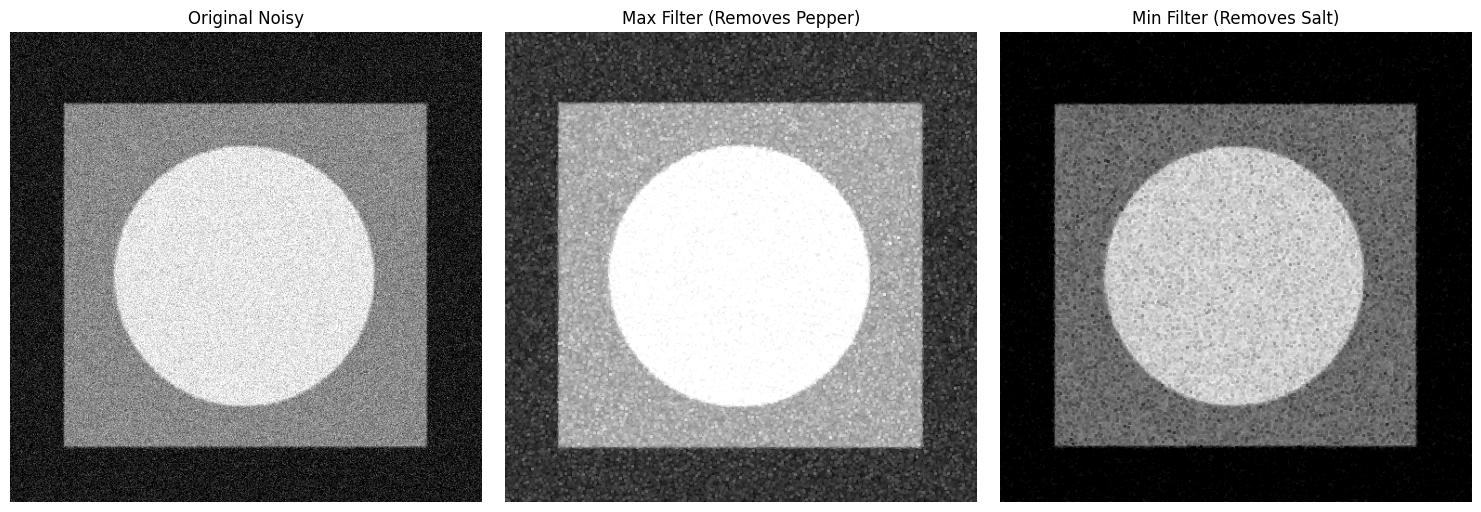

In [16]:


# === List of noisy images
# noise_gauss = add_noise(img, "gaussian")
# noise_sp = add_noise(img, "salt_pepper")
# noise_expo = add_noise(img, "exponential")
# noise_uni = add_noise(img, "uniform")

noise_img = noise_gauss



# 2. Define the Kernel size (e.g., 3x3)
kernel = np.ones((3, 3), np.uint8)

# 3. Apply Max Filter (Dilation)
# This picks the brightest pixel in the neighborhood.
max_filter = cv2.dilate(noise_img, kernel)

# 4. Apply Min Filter (Erosion)
# This picks the darkest pixel in the neighborhood.
min_filter = cv2.erode(noise_img, kernel)

# --- Display Results ---
plt.figure(figsize=(15, 5))

plt.subplot(131), plt.imshow(noise_img, cmap='gray'), plt.title('Original Noisy')
plt.subplot(132), plt.imshow(max_filter, cmap='gray'), plt.title('Max Filter (Removes Pepper)')
plt.subplot(133), plt.imshow(min_filter, cmap='gray'), plt.title('Min Filter (Removes Salt)')

for ax in plt.gcf().axes: ax.axis('off')
plt.tight_layout()
plt.show()


## **Mid-Point Filtering**

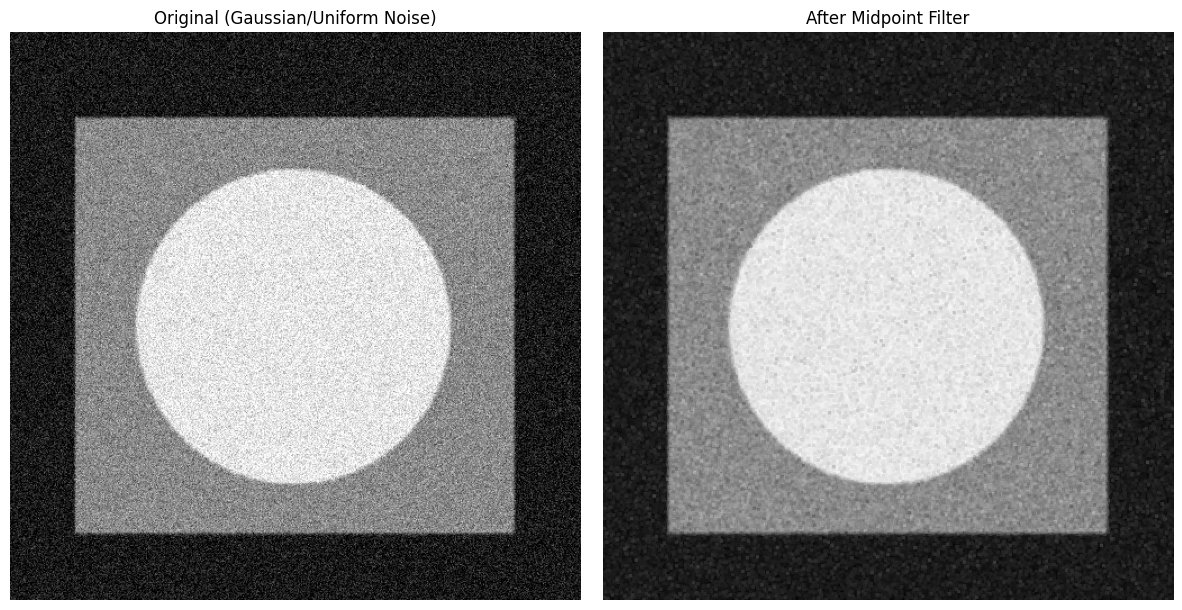

In [17]:

def midpoint_filter(image, kernel_size=3):
    # 1. Define the structural element (kernel)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    # 2. Find the Maximum value in the neighborhood (Dilation)
    max_img = cv2.dilate(image, kernel).astype(np.float64)

    # 3. Find the Minimum value in the neighborhood (Erosion)
    min_img = cv2.erode(image, kernel).astype(np.float64)

    # 4. Calculate the average of Max and Min
    midpoint = (max_img + min_img) / 2

    # 5. Convert back to 8-bit
    return midpoint.astype(np.uint8)



# === List of noisy images
# noise_gauss = add_noise(img, "gaussian")
# noise_sp = add_noise(img, "salt_pepper")
# noise_expo = add_noise(img, "exponential")
# noise_uni = add_noise(img, "uniform")

noise_img = noise_gauss


# Apply the Midpoint Filter
result = midpoint_filter(noise_img, kernel_size=3)

# --- Display Results ---
plt.figure(figsize=(12, 6))

plt.subplot(121), plt.imshow(noise_img, cmap='gray'), plt.title('Original (Gaussian/Uniform Noise)'), plt.axis('off')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('After Midpoint Filter'), plt.axis('off')

plt.tight_layout()
plt.show()
